In [18]:
import pickle
import os
import time
import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx

from shapely.geometry import Point
from urllib.parse import urljoin

In [19]:
with open("largest_river_component.pkl", "rb") as f:
    G_largest = pickle.load(f)

print("Nodes:", G_largest.number_of_nodes())
print("Edges:", G_largest.number_of_edges())
print("Directed:", G_largest.is_directed())

print(
    "Weak components:",
    nx.number_weakly_connected_components(G_largest)
)

print(
    "Stations already attached:",
    sum(
        data.get("station_count", 0)
        for _, data in G_largest.nodes(data=True)
    )
)

Nodes: 67401
Edges: 67400
Directed: True
Weak components: 1
Stations already attached: 29


In [20]:
test_node = next(iter(G_largest.nodes()))

print("Node:", test_node)
print("Attributes:")
print(G_largest.nodes[test_node])

Node: 36251195
Attributes:
{'longitude': -110.18416666666667, 'latitude': 42.1575, 'row': 2416, 'col': 8779, 'station_count': 0, 'stations': []}


In [21]:
print(
    "Longitude:",
    G_largest.nodes[test_node]["longitude"]
)

print(
    "Latitude:",
    G_largest.nodes[test_node]["latitude"]
)

Longitude: -110.18416666666667
Latitude: 42.1575


In [22]:
PARAM_GROUPS = {

    "DO concentration": [
        "00300"
    ],

    "DO saturation": [
        "00301"
    ],

    "Water temperature": [
        "00010"
    ],

    "Specific conductance": [
        "00095"
    ],

    "Turbidity": [
        "63680"
    ],

    "pH": [
        "00400"
    ],

    "Nitrate": [
        "99133"
    ],

    "Chlorophyll-a": [
        "32316",
        "32315"
    ],

    "fDOM/CDOM": [
        "32295",
        "32322"
    ],

    "Discharge": [
        "00060"
    ],

    "Stage": [
        "00065"
    ]
}

In [23]:
ALL_PCODES = sorted({
    code
    for codes in PARAM_GROUPS.values()
    for code in codes
})

print(ALL_PCODES)

['00010', '00060', '00065', '00095', '00300', '00301', '00400', '32295', '32315', '32316', '32322', '63680', '99133']


In [24]:
CORE_VARIABLES = [
    "DO concentration",
    "Water temperature",
    "Specific conductance",
    "Turbidity",
    "pH"
]

BONUS_VARIABLES = [
    "DO saturation",
    "Nitrate",
    "Chlorophyll-a",
    "fDOM/CDOM"
]

HYDRO_VARIABLES = [
    "Discharge",
    "Stage"
]

In [25]:
river_lons = [
    data["longitude"]
    for _, data in G_largest.nodes(data=True)
]

river_lats = [
    data["latitude"]
    for _, data in G_largest.nodes(data=True)
]

west = min(river_lons)
east = max(river_lons)
south = min(river_lats)
north = max(river_lats)

PAD = 0.15

west -= PAD
east += PAD
south -= PAD
north += PAD

bbox = f"{west},{south},{east},{north}"

print("Bounding box:")
print(bbox)

Bounding box:
-115.35166666666667,31.6675,-106.91083333333333,42.3075


In [62]:
from urllib.parse import urljoin

METADATA_URL = (
    "https://api.waterdata.usgs.gov/"
    "ogcapi/v1/collections/time-series-metadata/items"
)

USGS_API_KEY = "Wg8C6eEgjnC9TdHHYwnA1lBZXdJNVpYk5SDcH5Dr"

In [27]:
PCODE_TO_VARIABLE = {}

for variable, codes in PARAM_GROUPS.items():
    for code in codes:
        PCODE_TO_VARIABLE[code] = variable

PCODE_TO_VARIABLE

{'00300': 'DO concentration',
 '00301': 'DO saturation',
 '00010': 'Water temperature',
 '00095': 'Specific conductance',
 '63680': 'Turbidity',
 '00400': 'pH',
 '99133': 'Nitrate',
 '32316': 'Chlorophyll-a',
 '32315': 'Chlorophyll-a',
 '32295': 'fDOM/CDOM',
 '32322': 'fDOM/CDOM',
 '00060': 'Discharge',
 '00065': 'Stage'}

In [28]:
def get_all_features(url, params=None):

    features = []

    headers = {}

    if USGS_API_KEY is not None:
        headers["X-Api-Key"] = USGS_API_KEY

    first_request = True

    while url is not None:

        response = requests.get(
            url,
            params=params if first_request else None,
            headers=headers,
            timeout=120
        )

        response.raise_for_status()

        data = response.json()

        features.extend(
            data.get("features", [])
        )

        next_url = None

        for link in data.get("links", []):
            if link.get("rel") == "next":

                next_url = urljoin(
                    response.url,
                    link["href"]
                )

                break

        url = next_url
        first_request = False

    return features

In [29]:
all_metadata_features = []

for i, pcode in enumerate(ALL_PCODES, start=1):

    print(
        f"[{i}/{len(ALL_PCODES)}] "
        f"Searching {pcode}..."
    )

    params = {
        "f": "json",
        "limit": 1000,
        "bbox": bbox,
        "parameter_code": pcode
    }

    features = get_all_features(
        METADATA_URL,
        params=params
    )

    print(
        f"    {len(features):,} time series found"
    )

    all_metadata_features.extend(
        features
    )

    time.sleep(0.25)

[1/13] Searching 00010...
    1,446 time series found
[2/13] Searching 00060...
    5,362 time series found
[3/13] Searching 00065...
    2,913 time series found
[4/13] Searching 00095...
    852 time series found
[5/13] Searching 00300...
    330 time series found
[6/13] Searching 00301...
    40 time series found
[7/13] Searching 00400...
    330 time series found
[8/13] Searching 32295...
    7 time series found
[9/13] Searching 32315...
    10 time series found
[10/13] Searching 32316...
    0 time series found
[11/13] Searching 32322...
    0 time series found
[12/13] Searching 63680...
    339 time series found
[13/13] Searching 99133...
    3 time series found


In [30]:
metadata_rows = []

for feature in all_metadata_features:

    row = feature.get(
        "properties",
        {}
    ).copy()

    geometry = feature.get("geometry")

    if (
        geometry is not None
        and geometry.get("type") == "Point"
    ):

        coords = geometry.get(
            "coordinates",
            []
        )

        if len(coords) >= 2:
            row["longitude"] = coords[0]
            row["latitude"] = coords[1]

    metadata_rows.append(row)


usgs_metadata = pd.DataFrame(
    metadata_rows
)

print(
    "Total time-series metadata rows:",
    len(usgs_metadata)
)

print(
    "Unique monitoring locations:",
    usgs_metadata[
        "monitoring_location_id"
    ].nunique()
)

Total time-series metadata rows: 11632
Unique monitoring locations: 3060


In [31]:
print(
    usgs_metadata.columns.tolist()
)

['id', 'unit_of_measure', 'parameter_name', 'parameter_code', 'statistic_id', 'last_modified', 'begin', 'end', 'computation_period_identifier', 'computation_identifier', 'thresholds', 'sublocation_identifier', 'primary', 'monitoring_location_id', 'web_description', 'parameter_description', 'parent_time_series_id', 'data_gap_interval', 'statistics_begin', 'longitude', 'latitude']


In [32]:
continuous_metadata = usgs_metadata[
    (
        usgs_metadata[
            "computation_identifier"
        ]
        .fillna("")
        .str.lower()
        == "instantaneous"
    )
    &
    (
        usgs_metadata[
            "computation_period_identifier"
        ]
        .fillna("")
        .str.lower()
        == "points"
    )
].copy()


print(
    "Continuous time series:",
    len(continuous_metadata)
)

print(
    "Continuous monitoring stations:",
    continuous_metadata[
        "monitoring_location_id"
    ].nunique()
)

Continuous time series: 3258
Continuous monitoring stations: 1350


In [33]:
continuous_metadata = usgs_metadata[
    (
        usgs_metadata[
            "computation_identifier"
        ]
        .fillna("")
        .str.lower()
        == "instantaneous"
    )
    &
    (
        usgs_metadata[
            "computation_period_identifier"
        ]
        .fillna("")
        .str.lower()
        == "points"
    )
].copy()


print(
    "Continuous time series:",
    len(continuous_metadata)
)

print(
    "Continuous monitoring stations:",
    continuous_metadata[
        "monitoring_location_id"
    ].nunique()
)

Continuous time series: 3258
Continuous monitoring stations: 1350


In [34]:
continuous_metadata[
    "parameter_code"
] = (
    continuous_metadata[
        "parameter_code"
    ]
    .astype(str)
    .str.zfill(5)
)


continuous_metadata[
    "variable"
] = (
    continuous_metadata[
        "parameter_code"
    ]
    .map(PCODE_TO_VARIABLE)
)

In [35]:
print(
    continuous_metadata[
        "variable"
    ].value_counts()
)

variable
Discharge               1036
Stage                    761
Water temperature        542
Specific conductance     295
DO concentration         199
pH                       189
Turbidity                185
DO saturation             40
Chlorophyll-a             10
fDOM/CDOM                  1
Name: count, dtype: int64


In [36]:
river_node_records = []

for node, data in G_largest.nodes(data=True):

    river_node_records.append({
        "river_node": node,

        "geometry": Point(
            data["longitude"],
            data["latitude"]
        )
    })


river_nodes_gdf = gpd.GeoDataFrame(
    river_node_records,
    geometry="geometry",
    crs="EPSG:4326"
)

print(
    "River nodes:",
    len(river_nodes_gdf)
)

River nodes: 67401


In [37]:
usgs_sites = (
    continuous_metadata[
        [
            "monitoring_location_id",
            "longitude",
            "latitude"
        ]
    ]
    .dropna(
        subset=[
            "longitude",
            "latitude"
        ]
    )
    .drop_duplicates(
        subset="monitoring_location_id"
    )
    .copy()
)


usgs_sites_gdf = gpd.GeoDataFrame(
    usgs_sites,
    geometry=gpd.points_from_xy(
        usgs_sites["longitude"],
        usgs_sites["latitude"]
    ),
    crs="EPSG:4326"
)

print(
    "Continuous USGS sites:",
    len(usgs_sites_gdf)
)

Continuous USGS sites: 1350


In [38]:
PROJECTED_CRS = "EPSG:5070"

river_nodes_m = (
    river_nodes_gdf
    .to_crs(PROJECTED_CRS)
)

usgs_sites_m = (
    usgs_sites_gdf
    .to_crs(PROJECTED_CRS)
)

In [39]:
usgs_matches = gpd.sjoin_nearest(
    usgs_sites_m,
    river_nodes_m,
    how="left",
    distance_col="distance_to_river_m"
)

usgs_matches = (
    usgs_matches
    .sort_values(
        "distance_to_river_m"
    )
    .drop_duplicates(
        subset="monitoring_location_id"
    )
    .reset_index(drop=True)
)

print(
    "USGS stations matched:",
    len(usgs_matches)
)

USGS stations matched: 1350


In [40]:
for distance in [
    25,
    50,
    100,
    150,
    250,
    500,
    1000
]:

    count = (
        usgs_matches[
            "distance_to_river_m"
        ] <= distance
    ).sum()

    print(
        f"Within {distance:>4} m: "
        f"{count:,} stations"
    )

Within   25 m: 25 stations
Within   50 m: 83 stations
Within  100 m: 165 stations
Within  150 m: 185 stations
Within  250 m: 205 stations
Within  500 m: 269 stations
Within 1000 m: 315 stations


In [41]:
MAX_DISTANCE_M = 250

river_usgs_sites = usgs_matches[
    usgs_matches[
        "distance_to_river_m"
    ] <= MAX_DISTANCE_M
].copy()

print(
    "Continuous USGS stations near river:",
    len(river_usgs_sites)
)

Continuous USGS stations near river: 205


In [42]:
river_site_ids = set(
    river_usgs_sites[
        "monitoring_location_id"
    ]
)


river_continuous_metadata = (
    continuous_metadata[
        continuous_metadata[
            "monitoring_location_id"
        ].isin(river_site_ids)
    ]
    .copy()
)


print(
    "Stations:",
    river_continuous_metadata[
        "monitoring_location_id"
    ].nunique()
)

print(
    "Continuous time series:",
    len(river_continuous_metadata)
)

Stations: 205
Continuous time series: 645


In [43]:
availability = pd.crosstab(
    river_continuous_metadata[
        "monitoring_location_id"
    ],

    river_continuous_metadata[
        "variable"
    ]
).gt(0)

In [44]:
ALL_VARIABLES = [
    "DO concentration",
    "DO saturation",
    "Water temperature",
    "Specific conductance",
    "Turbidity",
    "pH",
    "Nitrate",
    "Chlorophyll-a",
    "fDOM/CDOM",
    "Stage",
    "Discharge"
]


for variable in ALL_VARIABLES:

    if variable not in availability.columns:
        availability[variable] = False


availability = availability[
    ALL_VARIABLES
]

In [45]:
availability[
    "core_variables"
] = (
    availability[
        CORE_VARIABLES
    ]
    .sum(axis=1)
)


availability[
    "bonus_variables"
] = (
    availability[
        BONUS_VARIABLES
    ]
    .sum(axis=1)
)


availability[
    "has_hydrology"
] = (
    availability["Stage"]
    |
    availability["Discharge"]
)


ranked_sites = (
    availability
    .sort_values(
        [
            "core_variables",
            "bonus_variables",
            "has_hydrology"
        ],
        ascending=False
    )
)


ranked_sites.head(30)

variable,DO concentration,DO saturation,Water temperature,Specific conductance,Turbidity,pH,Nitrate,Chlorophyll-a,fDOM/CDOM,Stage,Discharge,core_variables,bonus_variables,has_hydrology
monitoring_location_id,,,,,,,,,,,,,,
USGS-09071750,True,False,True,True,True,True,False,False,True,False,False,5,1,False
USGS-09070500,True,False,True,True,True,True,False,False,False,True,True,5,0,True
USGS-09085000,True,False,True,True,True,True,False,False,False,True,True,5,0,True
USGS-09092570,True,False,True,True,True,True,False,False,False,True,True,5,0,True
USGS-09095500,True,False,True,True,True,True,False,False,False,True,True,5,0,True
USGS-09144250,True,False,True,True,True,True,False,False,False,True,True,5,0,True
USGS-09152500,True,False,True,True,True,True,False,False,False,True,True,5,0,True
USGS-09163500,True,False,True,True,True,True,False,False,False,True,True,5,0,True
USGS-09180500,True,False,True,True,True,True,False,False,False,True,True,5,0,True


In [46]:
river_usgs_sites = usgs_matches[
    usgs_matches["distance_to_river_m"] <= 250
].copy()

In [47]:
from shapely.geometry import LineString

edge_records = []

for u, v in G_largest.edges():

    lon1 = G_largest.nodes[u]["longitude"]
    lat1 = G_largest.nodes[u]["latitude"]

    lon2 = G_largest.nodes[v]["longitude"]
    lat2 = G_largest.nodes[v]["latitude"]

    edge_records.append({
        "u": u,
        "v": v,
        "geometry": LineString([
            (lon1, lat1),
            (lon2, lat2)
        ])
    })

river_edges_gdf = gpd.GeoDataFrame(
    edge_records,
    geometry="geometry",
    crs="EPSG:4326"
)

print("River edges:", len(river_edges_gdf))

River edges: 67400


In [48]:
river_edges_m = river_edges_gdf.to_crs(
    "EPSG:5070"
)

In [49]:
usgs_edge_matches = gpd.sjoin_nearest(
    usgs_sites_m,
    river_edges_m[
        ["u", "v", "geometry"]
    ],
    how="left",
    distance_col="distance_to_river_edge_m"
)

In [50]:
usgs_edge_matches = (
    usgs_edge_matches
    .sort_values("distance_to_river_edge_m")
    .drop_duplicates(
        subset="monitoring_location_id"
    )
    .reset_index(drop=True)
)

In [51]:
for distance in [
    25,
    50,
    100,
    150,
    250
]:

    count = (
        usgs_edge_matches[
            "distance_to_river_edge_m"
        ] <= distance
    ).sum()

    print(
        f"Within {distance:>3} m: "
        f"{count} stations"
    )

Within  25 m: 41 stations
Within  50 m: 98 stations
Within 100 m: 171 stations
Within 150 m: 185 stations
Within 250 m: 206 stations


In [54]:
MAX_RIVER_DISTANCE = 100

river_usgs_sites = usgs_edge_matches[
    usgs_edge_matches[
        "distance_to_river_edge_m"
    ] <= MAX_RIVER_DISTANCE
].copy()

print(
    "USGS continuous stations on/very near river:",
    len(river_usgs_sites)
)

USGS continuous stations on/very near river: 171


In [55]:
FLOWING_TYPES = [
    "stream",
    "river",
    "canal",
    "channel"
]

In [56]:
[col for col in continuous_metadata.columns
 if "type" in col.lower() or "location" in col.lower()]

['sublocation_identifier', 'monitoring_location_id']

In [58]:
import time
import requests
from urllib.parse import urljoin


def get_all_features(url, params=None):

    features = []
    headers = {}

    if USGS_API_KEY:
        headers["X-Api-Key"] = USGS_API_KEY

    first_request = True

    while url is not None:

        while True:

            response = requests.get(
                url,
                params=params if first_request else None,
                headers=headers,
                timeout=120
            )

            # -----------------------
            # Handle rate limiting
            # -----------------------
            if response.status_code == 429:

                retry_after = response.headers.get(
                    "Retry-After"
                )

                if retry_after is not None:
                    wait_time = int(retry_after)
                else:
                    wait_time = 30

                print(
                    f"Rate limit hit. "
                    f"Waiting {wait_time} seconds..."
                )

                time.sleep(wait_time)

                continue

            response.raise_for_status()

            break

        data = response.json()

        features.extend(
            data.get("features", [])
        )

        print(
            f"Downloaded {len(features):,} records so far..."
        )

        # Optional: show rate limit
        remaining = response.headers.get(
            "X-RateLimit-Remaining"
        )

        if remaining is not None:
            print(
                "Requests remaining:",
                remaining
            )

        next_url = None

        for link in data.get(
            "links",
            []
        ):

            if link.get("rel") == "next":

                next_url = urljoin(
                    response.url,
                    link["href"]
                )

                break

        url = next_url
        first_request = False

        # Be nice to the API
        time.sleep(0.5)

    return features

In [ ]:
MONITORING_URL = (
    "https://api.waterdata.usgs.gov/"
    "ogcapi/v1/collections/"
    "monitoring-locations/items"
)

monitoring_features = get_all_features(
    MONITORING_URL,
    params={
        "f": "json",
        "limit": 1000,
        "bbox": bbox
    }
)

print(
    "Monitoring locations downloaded:",
    len(monitoring_features)
)

Continuous station IDs: 1350


In [60]:
continuous_metadata["monitoring_location_id"]

0               USGS-09414975
1        USGS-360700114505109
4               USGS-09504350
6               USGS-09328910
9               USGS-09505800
                 ...         
11621    USGS-393259107194801
11624    USGS-352550114390712
11626    USGS-360310114172321
11627    USGS-360310114172356
11628    USGS-360314114450510
Name: monitoring_location_id, Length: 3258, dtype: str

In [61]:
continuous_site_ids = (
    continuous_metadata[
        "monitoring_location_id"
    ]
    .dropna()
    .unique()
)

print(
    "Continuous station IDs:",
    len(continuous_site_ids)
)

Continuous station IDs: 1350


In [64]:
import requests
import time
import pandas as pd


MONITORING_URL = (
    "https://api.waterdata.usgs.gov/"
    "ogcapi/v1/collections/monitoring-locations/items"
)


continuous_site_ids = (
    continuous_metadata["monitoring_location_id"]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

print("Continuous station IDs:", len(continuous_site_ids))

Continuous station IDs: 1350


In [65]:
def chunks(lst, size):
    for i in range(0, len(lst), size):
        yield lst[i:i + size]


def get_monitoring_locations(site_ids, batch_size=100):

    all_features = []

    headers = {
        "Content-Type": "application/query-cql-json"
    }

    if USGS_API_KEY:
        headers["X-Api-Key"] = USGS_API_KEY

    batches = list(
        chunks(site_ids, batch_size)
    )

    for i, batch in enumerate(batches, start=1):

        print(
            f"[{i}/{len(batches)}] "
            f"Requesting {len(batch)} stations..."
        )

        query = {
            "op": "in",
            "args": [
                {"property": "id"},
                batch
            ]
        }

        while True:

            response = requests.post(
                MONITORING_URL,
                params={
                    "f": "json",
                    "limit": 1000
                },
                headers=headers,
                json=query,
                timeout=120
            )

            if response.status_code == 429:

                retry_after = response.headers.get(
                    "Retry-After"
                )

                wait_time = (
                    int(retry_after)
                    if retry_after
                    else 30
                )

                print(
                    f"Rate limited. Waiting "
                    f"{wait_time} seconds..."
                )

                time.sleep(wait_time)
                continue

            response.raise_for_status()
            break

        data = response.json()

        features = data.get(
            "features",
            []
        )

        all_features.extend(features)

        print(
            f"    returned {len(features)}"
            f" | total {len(all_features)}"
        )

        # Small delay to avoid another 429
        time.sleep(1)

    return all_features

In [66]:
monitoring_features = get_monitoring_locations(
    continuous_site_ids,
    batch_size=100
)

print(
    "\nMonitoring locations downloaded:",
    len(monitoring_features)
)

[1/14] Requesting 100 stations...
    returned 100 | total 100
[2/14] Requesting 100 stations...
    returned 100 | total 200
[3/14] Requesting 100 stations...
    returned 100 | total 300
[4/14] Requesting 100 stations...
    returned 100 | total 400
[5/14] Requesting 100 stations...
    returned 100 | total 500
[6/14] Requesting 100 stations...
    returned 100 | total 600
[7/14] Requesting 100 stations...
    returned 100 | total 700
[8/14] Requesting 100 stations...
    returned 100 | total 800
[9/14] Requesting 100 stations...
    returned 100 | total 900
[10/14] Requesting 100 stations...
    returned 100 | total 1000
[11/14] Requesting 100 stations...
    returned 100 | total 1100
[12/14] Requesting 100 stations...
    returned 100 | total 1200
[13/14] Requesting 100 stations...
    returned 100 | total 1300
[14/14] Requesting 50 stations...
    returned 50 | total 1350

Monitoring locations downloaded: 1350


In [67]:
monitoring_rows = []

for feature in monitoring_features:

    row = feature.get(
        "properties",
        {}
    ).copy()

    geometry = feature.get("geometry")

    if (
        geometry
        and geometry.get("type") == "Point"
    ):

        coords = geometry.get(
            "coordinates",
            []
        )

        if len(coords) >= 2:
            row["longitude"] = coords[0]
            row["latitude"] = coords[1]

    monitoring_rows.append(row)


site_metadata = pd.DataFrame(
    monitoring_rows
)

print("Rows:", len(site_metadata))
print(site_metadata.columns.tolist())

Rows: 1350
['id', 'agency_code', 'agency_name', 'monitoring_location_number', 'monitoring_location_name', 'district_code', 'country_code', 'country_name', 'state_code', 'state_name', 'county_code', 'county_name', 'minor_civil_division_code', 'site_type_code', 'site_type', 'hydrologic_unit_code', 'basin_code', 'altitude', 'altitude_accuracy', 'altitude_method_code', 'altitude_method_name', 'vertical_datum', 'vertical_datum_name', 'horizontal_positional_accuracy_code', 'horizontal_positional_accuracy', 'horizontal_position_method_code', 'horizontal_position_method_name', 'original_horizontal_datum', 'original_horizontal_datum_name', 'drainage_area', 'contributing_drainage_area', 'time_zone_abbreviation', 'uses_daylight_savings', 'construction_date', 'aquifer_code', 'national_aquifer_code', 'aquifer_type_code', 'well_constructed_depth', 'hole_constructed_depth', 'depth_source_code', 'revision_note', 'revision_created', 'revision_modified', 'longitude', 'latitude']


In [68]:
print(
    site_metadata[
        ["site_type_code", "site_type"]
    ]
    .value_counts()
    .to_string()
)

site_type_code  site_type                   
ST              Stream                          1013
LK              Lake, Reservoir, Impoundment     174
ST-CA           Canal                             57
GW              Well                              46
ST-DCH          Ditch                             37
SP              Spring                            12
FA-DV           Diversion                          9
WE              Wetland                            1
FA-STS          Storm sewer                        1


In [69]:
site_type_lookup = (
    site_metadata[
        [
            "id",
            "site_type_code",
            "site_type"
        ]
    ]
    .drop_duplicates(subset="id")
    .rename(columns={
        "id": "monitoring_location_id"
    })
)

# Makes this cell safe to rerun
continuous_metadata = continuous_metadata.drop(
    columns=[
        "site_type_code",
        "site_type"
    ],
    errors="ignore"
)

continuous_metadata = continuous_metadata.merge(
    site_type_lookup,
    on="monitoring_location_id",
    how="left"
)

print(
    continuous_metadata[
        [
            "monitoring_location_id",
            "site_type_code",
            "site_type"
        ]
    ]
    .drop_duplicates()
    ["site_type"]
    .value_counts()
)

site_type
Stream                          1013
Lake, Reservoir, Impoundment     174
Canal                             57
Well                              46
Ditch                             37
Spring                            12
Diversion                          9
Wetland                            1
Storm sewer                        1
Name: count, dtype: int64


In [70]:
FLOWING_CODES = [
    "ST",       # Stream
    "ST-CA",    # Canal
    "ST-DCH"    # Ditch
]

flowing_metadata = continuous_metadata[
    continuous_metadata[
        "site_type_code"
    ].isin(FLOWING_CODES)
].copy()

print(
    "All continuous stations:",
    continuous_metadata[
        "monitoring_location_id"
    ].nunique()
)

print(
    "Flowing-water stations:",
    flowing_metadata[
        "monitoring_location_id"
    ].nunique()
)

All continuous stations: 1350
Flowing-water stations: 1107


In [71]:
print(
    flowing_metadata[
        [
            "monitoring_location_id",
            "site_type_code",
            "site_type"
        ]
    ]
    .drop_duplicates()
    ["site_type"]
    .value_counts()
)

site_type
Stream    1013
Canal       57
Ditch       37
Name: count, dtype: int64


In [72]:
usgs_sites = (
    flowing_metadata[
        [
            "monitoring_location_id",
            "longitude",
            "latitude"
        ]
    ]
    .dropna(
        subset=[
            "longitude",
            "latitude"
        ]
    )
    .drop_duplicates(
        subset="monitoring_location_id"
    )
    .copy()
)

usgs_sites_gdf = gpd.GeoDataFrame(
    usgs_sites,
    geometry=gpd.points_from_xy(
        usgs_sites["longitude"],
        usgs_sites["latitude"]
    ),
    crs="EPSG:4326"
)

print(
    "Flowing-water USGS sites:",
    len(usgs_sites_gdf)
)

Flowing-water USGS sites: 1107


In [73]:
from shapely.geometry import LineString

edge_records = []

for u, v in G_largest.edges():

    u_data = G_largest.nodes[u]
    v_data = G_largest.nodes[v]

    edge_records.append({
        "u": u,
        "v": v,
        "geometry": LineString([
            (
                u_data["longitude"],
                u_data["latitude"]
            ),
            (
                v_data["longitude"],
                v_data["latitude"]
            )
        ])
    })

river_edges_gdf = gpd.GeoDataFrame(
    edge_records,
    geometry="geometry",
    crs="EPSG:4326"
)

print("River edges:", len(river_edges_gdf))

River edges: 67400


In [74]:
PROJECTED_CRS = "EPSG:5070"

river_edges_m = river_edges_gdf.to_crs(
    PROJECTED_CRS
)

usgs_sites_m = usgs_sites_gdf.to_crs(
    PROJECTED_CRS
)

print("River edges:", len(river_edges_m))
print("USGS flowing-water sites:", len(usgs_sites_m))

River edges: 67400
USGS flowing-water sites: 1107


In [75]:
usgs_edge_matches = gpd.sjoin_nearest(
    usgs_sites_m,
    river_edges_m[
        [
            "u",
            "v",
            "geometry"
        ]
    ],
    how="left",
    distance_col="distance_to_river_m"
)

In [76]:
usgs_edge_matches = (
    usgs_edge_matches
    .sort_values(
        "distance_to_river_m"
    )
    .drop_duplicates(
        subset="monitoring_location_id"
    )
    .reset_index(drop=True)
)

print(
    "Stations matched:",
    len(usgs_edge_matches)
)

Stations matched: 1107


In [77]:
for distance in [
    25,
    50,
    75,
    100,
    150,
    200,
    250,
    500,
    1000
]:

    count = (
        usgs_edge_matches[
            "distance_to_river_m"
        ] <= distance
    ).sum()

    print(
        f"Within {distance:>4} m: "
        f"{count:,}"
    )

Within   25 m: 41
Within   50 m: 74
Within   75 m: 104
Within  100 m: 126
Within  150 m: 138
Within  200 m: 146
Within  250 m: 149
Within  500 m: 179
Within 1000 m: 204


In [78]:
usgs_edge_matches[
    "distance_to_river_m"
].describe(
    percentiles=[
        .25,
        .50,
        .75,
        .90,
        .95,
        .99
    ]
)

count    1.107000e+03
mean     6.443003e+04
std      6.910206e+04
min      1.417808e-09
25%      7.148625e+03
50%      4.612712e+04
75%      9.638384e+04
90%      1.666556e+05
95%      1.918744e+05
99%      2.967579e+05
max      4.348593e+05
Name: distance_to_river_m, dtype: float64

In [ ]:
MAX_RIVER_DISTANCE_M = 150

river_usgs_sites = (
    usgs_edge_matches[
        usgs_edge_matches[
            "distance_to_river_m"
        ] <= MAX_RIVER_DISTANCE_M
    ]
    .copy()
)

print(
    "Flowing-water continuous stations "
    "within 150 m of river:",
    len(river_usgs_sites)
)

Flowing-water continuous stations within 100 m of river: 126


In [82]:
river_site_ids = set(
    river_usgs_sites[
        "monitoring_location_id"
    ]
)

river_site_types = (
    flowing_metadata[
        flowing_metadata[
            "monitoring_location_id"
        ].isin(river_site_ids)
    ]
    [
        [
            "monitoring_location_id",
            "site_type_code",
            "site_type"
        ]
    ]
    .drop_duplicates()
)

print(
    river_site_types[
        "site_type"
    ].value_counts()
)

site_type
Stream    118
Ditch       4
Canal       4
Name: count, dtype: int64


In [83]:
river_continuous_metadata = (
    flowing_metadata[
        flowing_metadata[
            "monitoring_location_id"
        ].isin(river_site_ids)
    ]
    .copy()
)

print(
    "Stations:",
    river_continuous_metadata[
        "monitoring_location_id"
    ].nunique()
)

print(
    "Continuous time series:",
    len(river_continuous_metadata)
)

Stations: 126
Continuous time series: 327


In [84]:
availability = pd.crosstab(
    river_continuous_metadata[
        "monitoring_location_id"
    ],
    river_continuous_metadata[
        "variable"
    ]
).gt(0)

In [85]:
ALL_VARIABLES = [
    "DO concentration",
    "DO saturation",
    "Water temperature",
    "Specific conductance",
    "Turbidity",
    "pH",
    "Nitrate",
    "Chlorophyll-a",
    "fDOM/CDOM",
    "Stage",
    "Discharge"
]

for variable in ALL_VARIABLES:

    if variable not in availability.columns:
        availability[variable] = False

availability = availability[
    ALL_VARIABLES
]

In [86]:
station_info = (
    river_usgs_sites[
        [
            "monitoring_location_id",
            "distance_to_river_m"
        ]
    ]
    .copy()
)

station_info = station_info.merge(
    river_site_types,
    on="monitoring_location_id",
    how="left"
)

station_info = station_info.set_index(
    "monitoring_location_id"
)

In [90]:
print(
    availability[
        [
            "site_type_code",
            "site_type",
            "distance_to_river_m"
        ]
    ].head()
)

                       site_type_code site_type  distance_to_river_m
monitoring_location_id                                              
USGS-09070500                      ST    Stream            49.806093
USGS-09071750                      ST    Stream            75.552420
USGS-09085100                      ST    Stream             4.596646
USGS-09085150                      ST    Stream             0.037356
USGS-09085160                      ST    Stream            31.129636


In [92]:
print(
    availability[
        [
            "site_type_code",
            "site_type",
            "distance_to_river_m"
        ]
    ].head()
)

                       site_type_code site_type  distance_to_river_m
monitoring_location_id                                              
USGS-09070500                      ST    Stream            49.806093
USGS-09071750                      ST    Stream            75.552420
USGS-09085100                      ST    Stream             4.596646
USGS-09085150                      ST    Stream             0.037356
USGS-09085160                      ST    Stream            31.129636


In [93]:
CORE_VARIABLES = [
    "DO concentration",
    "Water temperature",
    "Specific conductance",
    "Turbidity",
    "pH"
]

BONUS_VARIABLES = [
    "DO saturation",
    "Nitrate",
    "Chlorophyll-a",
    "fDOM/CDOM"
]

availability["core_count"] = (
    availability[CORE_VARIABLES]
    .sum(axis=1)
)

availability["bonus_count"] = (
    availability[BONUS_VARIABLES]
    .sum(axis=1)
)

availability["has_hydrology"] = (
    availability["Stage"]
    |
    availability["Discharge"]
)

In [94]:
ranked_sites = (
    availability
    .sort_values(
        [
            "core_count",
            "bonus_count",
            "has_hydrology",
            "distance_to_river_m"
        ],
        ascending=[
            False,
            False,
            False,
            True
        ]
    )
)

ranked_sites.head(30)

,DO concentration,DO saturation,Water temperature,Specific conductance,Turbidity,pH,Nitrate,Chlorophyll-a,fDOM/CDOM,Stage,Discharge,site_type_code,site_type,distance_to_river_m,core_count,bonus_count,has_hydrology
monitoring_location_id,,,,,,,,,,,,,,,,,
USGS-09071750,True,False,True,True,True,True,False,False,True,False,False,ST,Stream,7.555242e+01,5,1,False
USGS-09092570,True,False,True,True,True,True,False,False,False,True,True,ST,Stream,3.318171e-07,5,0,True
USGS-09095500,True,False,True,True,True,True,False,False,False,True,True,ST,Stream,2.281560e+00,5,0,True
USGS-09379500,True,False,True,True,True,True,False,False,False,True,True,ST,Stream,1.230243e+01,5,0,True
USGS-09152500,True,False,True,True,True,True,False,False,False,True,True,ST,Stream,1.631311e+01,5,0,True
USGS-09144250,True,False,True,True,True,True,False,False,False,True,True,ST,Stream,2.482770e+01,5,0,True
USGS-09070500,True,False,True,True,True,True,False,False,False,True,True,ST,Stream,4.980609e+01,5,0,True
USGS-393259107194801,True,False,True,True,True,True,False,False,False,True,False,ST,Stream,6.244569e+01,5,0,True
USGS-09180500,True,False,True,True,True,True,False,False,False,True,True,ST,Stream,6.890534e+01,5,0,True


In [95]:
full_core = ranked_sites[
    ranked_sites[CORE_VARIABLES].all(axis=1)
]

full_core_hydro = full_core[
    full_core["has_hydrology"]
]

print("Stations with all 5 core variables:", len(full_core))
print("Stations with all 5 core variables + hydrology:", len(full_core_hydro))

full_core_hydro.head(30)

Stations with all 5 core variables: 13
Stations with all 5 core variables + hydrology: 10


,DO concentration,DO saturation,Water temperature,Specific conductance,Turbidity,pH,Nitrate,Chlorophyll-a,fDOM/CDOM,Stage,Discharge,site_type_code,site_type,distance_to_river_m,core_count,bonus_count,has_hydrology
monitoring_location_id,,,,,,,,,,,,,,,,,
USGS-09092570,True,False,True,True,True,True,False,False,False,True,True,ST,Stream,3.318171e-07,5,0,True
USGS-09095500,True,False,True,True,True,True,False,False,False,True,True,ST,Stream,2.281560e+00,5,0,True
USGS-09379500,True,False,True,True,True,True,False,False,False,True,True,ST,Stream,1.230243e+01,5,0,True
USGS-09152500,True,False,True,True,True,True,False,False,False,True,True,ST,Stream,1.631311e+01,5,0,True
USGS-09144250,True,False,True,True,True,True,False,False,False,True,True,ST,Stream,2.482770e+01,5,0,True
USGS-09070500,True,False,True,True,True,True,False,False,False,True,True,ST,Stream,4.980609e+01,5,0,True
USGS-393259107194801,True,False,True,True,True,True,False,False,False,True,False,ST,Stream,6.244569e+01,5,0,True
USGS-09180500,True,False,True,True,True,True,False,False,False,True,True,ST,Stream,6.890534e+01,5,0,True
USGS-09380000,True,False,True,True,True,True,False,False,False,True,True,ST,Stream,7.469462e+01,5,0,True


In [96]:
candidate_sites = full_core_hydro.index.tolist()

print("Candidate stations:", len(candidate_sites))

for site in candidate_sites:
    print(site)

Candidate stations: 10
USGS-09092570
USGS-09095500
USGS-09379500
USGS-09152500
USGS-09144250
USGS-09070500
USGS-393259107194801
USGS-09180500
USGS-09380000
USGS-09261000


In [97]:
print([
    col for col in river_continuous_metadata.columns
    if any(
        word in col.lower()
        for word in ["begin", "start", "end"]
    )
])

['begin', 'end', 'statistics_begin']


In [98]:
begin_col = next(
    col for col in [
        "begin_utc",
        "start",
        "begin"
    ]
    if col in river_continuous_metadata.columns
)

end_col = next(
    col for col in [
        "end_utc",
        "end"
    ]
    if col in river_continuous_metadata.columns
)

print("Beginning column:", begin_col)
print("Ending column:", end_col)

Beginning column: begin
Ending column: end


In [99]:
candidate_metadata = (
    river_continuous_metadata[
        river_continuous_metadata[
            "monitoring_location_id"
        ].isin(candidate_sites)
    ]
    .copy()
)

candidate_metadata["begin_dt"] = pd.to_datetime(
    candidate_metadata[begin_col],
    errors="coerce",
    utc=True
)

candidate_metadata["end_dt"] = pd.to_datetime(
    candidate_metadata[end_col],
    errors="coerce",
    utc=True
)

In [100]:
variable_windows = (
    candidate_metadata
    .groupby(
        [
            "monitoring_location_id",
            "variable"
        ]
    )
    .agg(
        first_observation=("begin_dt", "min"),
        last_observation=("end_dt", "max"),
        time_series_count=("parameter_code", "size")
    )
    .reset_index()
)

variable_windows

,monitoring_location_id,variable,first_observation,last_observation,time_series_count
0,USGS-09070500,DO concentration,2021-04-10 01:15:00+00:00,2026-09-26 10:00:00+00:00,1
1,USGS-09070500,Discharge,1986-04-11 14:00:00+00:00,2026-09-26 13:00:00+00:00,1
2,USGS-09070500,Specific conductance,2021-04-10 01:15:00+00:00,2026-09-26 10:00:00+00:00,1
3,USGS-09070500,Stage,2020-08-05 01:15:00+00:00,2026-09-26 14:00:00+00:00,1
4,USGS-09070500,Turbidity,2021-04-10 01:15:00+00:00,2026-09-26 10:00:00+00:00,1
...,...,...,...,...,...
64,USGS-393259107194801,Specific conductance,2021-09-24 13:00:00+00:00,2026-09-26 14:05:00+00:00,1
65,USGS-393259107194801,Stage,2023-09-11 06:00:00+00:00,2026-09-26 14:00:00+00:00,1
66,USGS-393259107194801,Turbidity,2021-09-24 13:00:00+00:00,2026-09-26 14:05:00+00:00,1
67,USGS-393259107194801,Water temperature,2021-09-24 13:00:00+00:00,2026-09-26 14:05:00+00:00,1


In [101]:
CORE_VARIABLES = [
    "DO concentration",
    "Water temperature",
    "Specific conductance",
    "Turbidity",
    "pH"
]


def find_common_window(site_id):

    site = variable_windows[
        variable_windows[
            "monitoring_location_id"
        ] == site_id
    ]

    starts = []
    ends = []

    # Core water-quality variables
    for variable in CORE_VARIABLES:

        rows = site[
            site["variable"] == variable
        ]

        if rows.empty:
            return None

        starts.append(
            rows["first_observation"].min()
        )

        ends.append(
            rows["last_observation"].max()
        )

    core_start = max(starts)
    core_end = min(ends)

    hydro_options = []

    for hydro_variable in [
        "Discharge",
        "Stage"
    ]:

        rows = site[
            site["variable"] == hydro_variable
        ]

        if rows.empty:
            continue

        hydro_start = rows[
            "first_observation"
        ].min()

        hydro_end = rows[
            "last_observation"
        ].max()

        common_start = max(
            core_start,
            hydro_start
        )

        common_end = min(
            core_end,
            hydro_end
        )

        if common_end > common_start:

            days = (
                common_end - common_start
            ).total_seconds() / 86400

            hydro_options.append({
                "hydrology": hydro_variable,
                "common_start": common_start,
                "common_end": common_end,
                "overlap_days": days
            })

    if not hydro_options:
        return None

    return max(
        hydro_options,
        key=lambda x: x["overlap_days"]
    )

In [102]:
overlap_rows = []

for site_id in candidate_sites:

    result = find_common_window(site_id)

    if result is None:
        continue

    overlap_rows.append({
        "station": site_id,
        **result
    })


overlap_table = (
    pd.DataFrame(overlap_rows)
    .sort_values(
        "overlap_days",
        ascending=False
    )
    .reset_index(drop=True)
)

overlap_table

,station,hydrology,common_start,common_end,overlap_days
0,USGS-09095500,Discharge,2020-08-28 01:30:00+00:00,2026-09-26 13:45:00+00:00,2220.510417
1,USGS-09070500,Discharge,2021-04-10 01:15:00+00:00,2026-09-26 10:00:00+00:00,1995.364583
2,USGS-09144250,Discharge,2021-06-24 04:30:00+00:00,2026-09-26 12:15:00+00:00,1920.322917
3,USGS-09152500,Discharge,2021-07-01 00:45:00+00:00,2026-09-26 13:30:00+00:00,1913.531250
4,USGS-09261000,Discharge,2021-10-29 03:15:00+00:00,2025-12-31 22:15:00+00:00,1524.791667
5,USGS-09379500,Discharge,2021-10-19 00:45:00+00:00,2025-12-05 04:00:00+00:00,1508.135417
6,USGS-09180500,Discharge,2021-11-10 02:00:00+00:00,2025-12-17 01:00:00+00:00,1497.958333
7,USGS-393259107194801,Stage,2023-09-11 06:00:00+00:00,2026-09-26 14:00:00+00:00,1111.333333
8,USGS-09380000,Discharge,2024-02-14 05:15:00+00:00,2026-09-26 14:00:00+00:00,955.364583
9,USGS-09092570,Discharge,2023-09-11 06:00:00+00:00,2024-11-01 12:45:00+00:00,417.281250


In [103]:
overlap_table["overlap_years"] = (
    overlap_table["overlap_days"] / 365.25
)

overlap_table[
    [
        "station",
        "hydrology",
        "common_start",
        "common_end",
        "overlap_years"
    ]
]

,station,hydrology,common_start,common_end,overlap_years
0,USGS-09095500,Discharge,2020-08-28 01:30:00+00:00,2026-09-26 13:45:00+00:00,6.079426
1,USGS-09070500,Discharge,2021-04-10 01:15:00+00:00,2026-09-26 10:00:00+00:00,5.463010
2,USGS-09144250,Discharge,2021-06-24 04:30:00+00:00,2026-09-26 12:15:00+00:00,5.257558
3,USGS-09152500,Discharge,2021-07-01 00:45:00+00:00,2026-09-26 13:30:00+00:00,5.238963
4,USGS-09261000,Discharge,2021-10-29 03:15:00+00:00,2025-12-31 22:15:00+00:00,4.174652
5,USGS-09379500,Discharge,2021-10-19 00:45:00+00:00,2025-12-05 04:00:00+00:00,4.129050
6,USGS-09180500,Discharge,2021-11-10 02:00:00+00:00,2025-12-17 01:00:00+00:00,4.101186
7,USGS-393259107194801,Stage,2023-09-11 06:00:00+00:00,2026-09-26 14:00:00+00:00,3.042665
8,USGS-09380000,Discharge,2024-02-14 05:15:00+00:00,2026-09-26 14:00:00+00:00,2.615646
9,USGS-09092570,Discharge,2023-09-11 06:00:00+00:00,2024-11-01 12:45:00+00:00,1.142454


In [104]:
CONTINUOUS_URL = (
    "https://api.waterdata.usgs.gov/"
    "ogcapi/v1/collections/continuous/items"
)

MIN_POINTS = 500

In [105]:
def count_points_until_threshold(
    site_id,
    pcode,
    start,
    end,
    threshold=500
):

    headers = {}

    if USGS_API_KEY:
        headers["X-Api-Key"] = USGS_API_KEY

    params = {
        "f": "json",
        "limit": 1000,
        "monitoring_location_id": site_id,
        "parameter_code": pcode,
        "datetime": (
            f"{start.strftime('%Y-%m-%d')}/"
            f"{end.strftime('%Y-%m-%d')}"
        )
    }

    url = CONTINUOUS_URL
    first_request = True

    timestamps = set()

    while url is not None:

        while True:

            response = requests.get(
                url,
                params=params if first_request else None,
                headers=headers,
                timeout=120
            )

            if response.status_code == 429:

                wait_time = int(
                    response.headers.get(
                        "Retry-After",
                        30
                    )
                )

                print(
                    f"Rate limit — waiting "
                    f"{wait_time}s"
                )

                time.sleep(wait_time)
                continue

            response.raise_for_status()
            break

        payload = response.json()

        for feature in payload.get(
            "features",
            []
        ):

            props = feature.get(
                "properties",
                {}
            )

            timestamp = props.get("time")
            value = props.get("value")

            # Count only real numeric values
            try:
                float(value)
                valid = True
            except (TypeError, ValueError):
                valid = False

            if (
                valid
                and timestamp is not None
            ):
                timestamps.add(timestamp)

            if len(timestamps) >= threshold:
                return len(timestamps)

        next_url = None

        for link in payload.get(
            "links",
            []
        ):

            if link.get("rel") == "next":

                next_url = urljoin(
                    response.url,
                    link["href"]
                )

                break

        url = next_url
        first_request = False

        time.sleep(0.25)

    return len(timestamps)

In [106]:
CORE_PCODES = {
    "DO concentration": "00300",
    "Water temperature": "00010",
    "Specific conductance": "00095",
    "Turbidity": "63680",
    "pH": "00400",

    "Discharge": "00060",
    "Stage": "00065"
}

In [107]:
validation_rows = []

for _, row in overlap_table.iterrows():

    site_id = row["station"]

    common_start = row["common_start"]
    common_end = row["common_end"]

    # Test the final year of the overlapping period
    test_start = max(
        common_start,
        common_end - pd.Timedelta(days=365)
    )

    test_end = common_end

    print("\n" + "=" * 60)
    print(site_id)
    print(
        test_start.date(),
        "to",
        test_end.date()
    )

    output = {
        "station": site_id,
        "start": test_start,
        "end": test_end
    }

    # Five core variables
    for variable in CORE_VARIABLES:

        pcode = CORE_PCODES[variable]

        count = count_points_until_threshold(
            site_id,
            pcode,
            test_start,
            test_end,
            MIN_POINTS
        )

        output[variable] = count

        print(
            f"{variable:25s}: "
            f"{count}"
        )

    # Chosen hydrology variable
    hydro_variable = row["hydrology"]
    hydro_pcode = CORE_PCODES[
        hydro_variable
    ]

    hydro_count = count_points_until_threshold(
        site_id,
        hydro_pcode,
        test_start,
        test_end,
        MIN_POINTS
    )

    output["Hydrology"] = hydro_count
    output["Hydrology_variable"] = (
        hydro_variable
    )

    print(
        f"{hydro_variable:25s}: "
        f"{hydro_count}"
    )

    validation_rows.append(output)


validation = pd.DataFrame(
    validation_rows
)


USGS-09095500
2025-09-26 to 2026-09-26
DO concentration         : 500
Water temperature        : 500
Specific conductance     : 500
Turbidity                : 500
pH                       : 500
Discharge                : 500

USGS-09070500
2025-09-26 to 2026-09-26
DO concentration         : 500
Water temperature        : 500
Specific conductance     : 500
Turbidity                : 500
pH                       : 500
Discharge                : 500

USGS-09144250
2025-09-26 to 2026-09-26
DO concentration         : 500
Water temperature        : 500
Specific conductance     : 500
Turbidity                : 500
pH                       : 500
Discharge                : 500

USGS-09152500
2025-09-26 to 2026-09-26
DO concentration         : 500
Water temperature        : 500
Specific conductance     : 500
Turbidity                : 500
pH                       : 500
Discharge                : 500

USGS-09261000
2024-12-31 to 2025-12-31
DO concentration         : 500
Water temperature        

In [108]:
REQUIRED_COUNT_COLUMNS = (
    CORE_VARIABLES
    + ["Hydrology"]
)

validation["variables_with_500+"] = (
    validation[
        REQUIRED_COUNT_COLUMNS
    ] >= MIN_POINTS
).sum(axis=1)

validation["passes_all"] = (
    validation[
        REQUIRED_COUNT_COLUMNS
    ] >= MIN_POINTS
).all(axis=1)

validation = validation.sort_values(
    "variables_with_500+",
    ascending=False
)

validation

,station,start,end,DO concentration,Water temperature,Specific conductance,Turbidity,pH,Hydrology,Hydrology_variable,variables_with_500+,passes_all
0,USGS-09095500,2025-09-26 13:45:00+00:00,2026-09-26 13:45:00+00:00,500,500,500,500,500,500,Discharge,6,True
1,USGS-09070500,2025-09-26 10:00:00+00:00,2026-09-26 10:00:00+00:00,500,500,500,500,500,500,Discharge,6,True
2,USGS-09144250,2025-09-26 12:15:00+00:00,2026-09-26 12:15:00+00:00,500,500,500,500,500,500,Discharge,6,True
3,USGS-09152500,2025-09-26 13:30:00+00:00,2026-09-26 13:30:00+00:00,500,500,500,500,500,500,Discharge,6,True
4,USGS-09261000,2024-12-31 22:15:00+00:00,2025-12-31 22:15:00+00:00,500,500,500,500,500,500,Discharge,6,True
5,USGS-09379500,2024-12-05 04:00:00+00:00,2025-12-05 04:00:00+00:00,500,500,500,500,500,500,Discharge,6,True
6,USGS-09180500,2024-12-17 01:00:00+00:00,2025-12-17 01:00:00+00:00,500,500,500,500,500,500,Discharge,6,True
7,USGS-393259107194801,2025-09-26 14:00:00+00:00,2026-09-26 14:00:00+00:00,500,500,500,500,500,500,Stage,6,True
8,USGS-09380000,2025-09-26 14:00:00+00:00,2026-09-26 14:00:00+00:00,500,500,500,500,500,500,Discharge,6,True
9,USGS-09092570,2023-11-02 12:45:00+00:00,2024-11-01 12:45:00+00:00,500,500,500,500,500,500,Discharge,6,True


In [109]:
ml_ready = validation[
    validation["passes_all"]
].copy()

print(
    "Stations with >=500 actual values "
    "for every core variable + hydrology:",
    len(ml_ready)
)

ml_ready

Stations with >=500 actual values for every core variable + hydrology: 10


,station,start,end,DO concentration,Water temperature,Specific conductance,Turbidity,pH,Hydrology,Hydrology_variable,variables_with_500+,passes_all
0,USGS-09095500,2025-09-26 13:45:00+00:00,2026-09-26 13:45:00+00:00,500,500,500,500,500,500,Discharge,6,True
1,USGS-09070500,2025-09-26 10:00:00+00:00,2026-09-26 10:00:00+00:00,500,500,500,500,500,500,Discharge,6,True
2,USGS-09144250,2025-09-26 12:15:00+00:00,2026-09-26 12:15:00+00:00,500,500,500,500,500,500,Discharge,6,True
3,USGS-09152500,2025-09-26 13:30:00+00:00,2026-09-26 13:30:00+00:00,500,500,500,500,500,500,Discharge,6,True
4,USGS-09261000,2024-12-31 22:15:00+00:00,2025-12-31 22:15:00+00:00,500,500,500,500,500,500,Discharge,6,True
5,USGS-09379500,2024-12-05 04:00:00+00:00,2025-12-05 04:00:00+00:00,500,500,500,500,500,500,Discharge,6,True
6,USGS-09180500,2024-12-17 01:00:00+00:00,2025-12-17 01:00:00+00:00,500,500,500,500,500,500,Discharge,6,True
7,USGS-393259107194801,2025-09-26 14:00:00+00:00,2026-09-26 14:00:00+00:00,500,500,500,500,500,500,Stage,6,True
8,USGS-09380000,2025-09-26 14:00:00+00:00,2026-09-26 14:00:00+00:00,500,500,500,500,500,500,Discharge,6,True
9,USGS-09092570,2023-11-02 12:45:00+00:00,2024-11-01 12:45:00+00:00,500,500,500,500,500,500,Discharge,6,True


In [110]:
ml_ready_sites = validation[
    validation["passes_all"]
]["station"].tolist()

print("ML-ready stations:", len(ml_ready_sites))

for site in ml_ready_sites:
    print(site)

ML-ready stations: 10
USGS-09095500
USGS-09070500
USGS-09144250
USGS-09152500
USGS-09261000
USGS-09379500
USGS-09180500
USGS-393259107194801
USGS-09380000
USGS-09092570


In [111]:
def download_continuous_data(
    site_id,
    pcode,
    start,
    end
):

    headers = {}

    if USGS_API_KEY:
        headers["X-Api-Key"] = USGS_API_KEY

    params = {
        "f": "json",
        "limit": 1000,
        "monitoring_location_id": site_id,
        "parameter_code": pcode,
        "datetime": (
            f"{start.strftime('%Y-%m-%d')}/"
            f"{end.strftime('%Y-%m-%d')}"
        )
    }

    url = CONTINUOUS_URL

    first_request = True
    rows = []

    while url is not None:

        while True:

            response = requests.get(
                url,
                params=params if first_request else None,
                headers=headers,
                timeout=120
            )

            if response.status_code == 429:

                wait_time = int(
                    response.headers.get(
                        "Retry-After",
                        30
                    )
                )

                print(
                    f"Rate limited. Waiting "
                    f"{wait_time}s..."
                )

                time.sleep(wait_time)
                continue

            response.raise_for_status()
            break

        payload = response.json()

        for feature in payload.get(
            "features",
            []
        ):

            props = feature.get(
                "properties",
                {}
            )

            rows.append(props)

        next_url = None

        for link in payload.get(
            "links",
            []
        ):

            if link.get("rel") == "next":

                next_url = urljoin(
                    response.url,
                    link["href"]
                )

                break

        url = next_url
        first_request = False

        time.sleep(0.2)

    df = pd.DataFrame(rows)

    return df

In [112]:
test_site = ml_ready_sites[0]

test_site

'USGS-09095500'

In [113]:
test_row = overlap_table[
    overlap_table["station"] == test_site
].iloc[0]

test_end = test_row["common_end"]

test_start = max(
    test_row["common_start"],
    test_end - pd.Timedelta(days=365)
)

print("Station:", test_site)
print("Start:", test_start)
print("End:", test_end)
print("Hydrology:", test_row["hydrology"])

Station: USGS-09095500
Start: 2025-09-26 13:45:00+00:00
End: 2026-09-26 13:45:00+00:00
Hydrology: Discharge


In [114]:
temp_test = download_continuous_data(
    test_site,
    "00010",
    test_start,
    test_end
)

print("Rows:", len(temp_test))
print(temp_test.columns.tolist())

temp_test.head()

Rows: 35016
['time_series_id', 'monitoring_location_id', 'parameter_code', 'statistic_id', 'time', 'value', 'unit_of_measure', 'approval_status', 'qualifier', 'last_modified', 'method_category']


,time_series_id,monitoring_location_id,parameter_code,statistic_id,time,value,unit_of_measure,approval_status,qualifier,last_modified,method_category
0,ad343296d3064d3ba376deaeed2a6fb7,USGS-09095500,00010,00011,2025-09-26T00:00:00+00:00,18.0,degC,Approved,None,2025-12-29T22:16:11.664321+00:00,STNRD
1,ad343296d3064d3ba376deaeed2a6fb7,USGS-09095500,00010,00011,2025-09-26T00:15:00+00:00,17.9,degC,Approved,None,2025-12-29T22:16:11.664321+00:00,STNRD
2,ad343296d3064d3ba376deaeed2a6fb7,USGS-09095500,00010,00011,2025-09-26T00:30:00+00:00,17.9,degC,Approved,None,2025-12-29T22:16:11.664321+00:00,STNRD
3,ad343296d3064d3ba376deaeed2a6fb7,USGS-09095500,00010,00011,2025-09-26T00:45:00+00:00,17.9,degC,Approved,None,2025-12-29T22:16:11.664321+00:00,STNRD
4,ad343296d3064d3ba376deaeed2a6fb7,USGS-09095500,00010,00011,2025-09-26T01:00:00+00:00,17.8,degC,Approved,None,2025-12-29T22:16:11.664321+00:00,STNRD


In [115]:
def clean_continuous_series(df, variable_name):

    df = df.copy()

    df["time"] = pd.to_datetime(
        df["time"],
        errors="coerce",
        utc=True
    )

    df["value"] = pd.to_numeric(
        df["value"],
        errors="coerce"
    )

    df = df.dropna(
        subset=["time", "value"]
    )

    # Prefer approved observations when available
    if "approval_status" in df.columns:
        approved = df[
            df["approval_status"]
            .fillna("")
            .str.lower()
            == "approved"
        ]

        if len(approved) > 0:
            df = approved

    # If multiple USGS time-series exist for this
    # parameter, use the one with the most observations.
    if (
        "time_series_id" in df.columns
        and df["time_series_id"].nunique() > 1
    ):

        best_series = (
            df["time_series_id"]
            .value_counts()
            .idxmax()
        )

        df = df[
            df["time_series_id"] == best_series
        ]

    df = (
        df[
            ["time", "value"]
        ]
        .drop_duplicates(
            subset="time",
            keep="first"
        )
        .sort_values("time")
        .rename(
            columns={
                "value": variable_name
            }
        )
    )

    return df

In [116]:
temperature_clean = clean_continuous_series(
    temp_test,
    "Water temperature"
)

print(
    "Clean observations:",
    len(temperature_clean)
)

temperature_clean.head()

Clean observations: 30669


,time,Water temperature
0,2025-09-26 00:00:00+00:00,18.0
1,2025-09-26 00:15:00+00:00,17.9
2,2025-09-26 00:30:00+00:00,17.9
3,2025-09-26 00:45:00+00:00,17.9
4,2025-09-26 01:00:00+00:00,17.8


In [117]:
temperature_clean["interval"] = (
    temperature_clean["time"]
    .diff()
)

print(
    temperature_clean["interval"]
    .value_counts()
    .head(10)
)

interval
0 days 00:15:00    30657
0 days 00:30:00        4
0 days 00:45:00        4
0 days 01:15:00        2
0 days 01:00:00        1
Name: count, dtype: int64


In [118]:
temperature_clean = temperature_clean.drop(
    columns="interval"
)

In [119]:
CORE_PCODES = {
    "DO concentration": "00300",
    "Water temperature": "00010",
    "Specific conductance": "00095",
    "Turbidity": "63680",
    "pH": "00400",

    "Discharge": "00060",
    "Stage": "00065"
}

In [120]:
test_site = ml_ready_sites[0]

test_overlap = overlap_table[
    overlap_table["station"] == test_site
].iloc[0]

test_end = test_overlap["common_end"]

test_start = max(
    test_overlap["common_start"],
    test_end - pd.Timedelta(days=365)
)

hydro_variable = test_overlap["hydrology"]

print("Station:", test_site)
print("Start:", test_start)
print("End:", test_end)
print("Hydrology:", hydro_variable)

Station: USGS-09095500
Start: 2025-09-26 13:45:00+00:00
End: 2026-09-26 13:45:00+00:00
Hydrology: Discharge


In [121]:
station_series = {}

variables_to_download = (
    CORE_VARIABLES
    + [hydro_variable]
)

for variable in variables_to_download:

    pcode = CORE_PCODES[variable]

    print(
        f"Downloading {variable} "
        f"({pcode})..."
    )

    raw = download_continuous_data(
        test_site,
        pcode,
        test_start,
        test_end
    )

    clean = clean_continuous_series(
        raw,
        variable
    )

    station_series[variable] = clean

    print(
        f"    {len(clean):,} observations"
    )

    22,034 observations
    30,669 observations
    30,343 observations
    20,876 observations
    22,034 observations
    16,918 observations


In [122]:
series_list = list(
    station_series.values()
)

station_ml = series_list[0]

In [123]:
for df in series_list[1:]:

    station_ml = station_ml.merge(
        df,
        on="time",
        how="inner"
    )

In [124]:
station_ml.insert(
    0,
    "station",
    test_site
)

In [125]:
print(
    "Synchronized rows:",
    len(station_ml)
)

station_ml.head()

Synchronized rows: 16875


,station,time,DO concentration,Water temperature,Specific conductance,Turbidity,pH,Discharge
0,USGS-09095500,2025-09-26 00:00:00+00:00,9.4,18.0,989,10.6,8.6,1950
1,USGS-09095500,2025-09-26 00:15:00+00:00,9.4,17.9,989,10.4,8.6,1950
2,USGS-09095500,2025-09-26 00:30:00+00:00,9.3,17.9,989,10.4,8.6,1950
3,USGS-09095500,2025-09-26 00:45:00+00:00,9.2,17.9,989,10.6,8.6,1950
4,USGS-09095500,2025-09-26 01:00:00+00:00,9.2,17.8,989,10.3,8.6,1950


In [126]:
station_outer = series_list[0]

for df in series_list[1:]:

    station_outer = station_outer.merge(
        df,
        on="time",
        how="outer"
    )

station_outer = station_outer.sort_values(
    "time"
)

In [127]:
completeness = pd.DataFrame({
    "observations": (
        station_outer
        .drop(columns="time")
        .count()
    ),

    "percent_complete": (
        station_outer
        .drop(columns="time")
        .notna()
        .mean()
        .mul(100)
        .round(2)
    )
})

completeness

,observations,percent_complete
DO concentration,22034,71.82
Water temperature,30669,99.96
Specific conductance,30343,98.90
Turbidity,20876,68.04
pH,22034,71.82
Discharge,16918,55.14


In [128]:
def clean_continuous_series(df, variable_name):

    df = df.copy()

    df["time"] = pd.to_datetime(
        df["time"],
        errors="coerce",
        utc=True
    )

    df["value"] = pd.to_numeric(
        df["value"],
        errors="coerce"
    )

    df = df.dropna(
        subset=["time", "value"]
    )

    # Prefer approved observations
    if "approval_status" in df.columns:

        approved = df[
            df["approval_status"]
            .fillna("")
            .str.lower()
            == "approved"
        ]

        if len(approved) > 0:
            df = approved

    # If duplicate timestamps exist, prefer the most recently
    # modified record.
    if "last_modified" in df.columns:

        df["last_modified"] = pd.to_datetime(
            df["last_modified"],
            errors="coerce",
            utc=True
        )

        df = df.sort_values(
            ["time", "last_modified"]
        )

    else:
        df = df.sort_values("time")

    df = (
        df
        .drop_duplicates(
            subset="time",
            keep="last"
        )
        [
            ["time", "value"]
        ]
        .rename(
            columns={
                "value": variable_name
            }
        )
        .sort_values("time")
        .reset_index(drop=True)
    )

    return df

In [129]:
for variable, df in station_series.items():

    intervals = (
        df["time"]
        .sort_values()
        .diff()
        .value_counts()
        .head(5)
    )

    print("\n", variable)
    print(intervals)


 DO concentration
time
0 days 00:15:00    22024
0 days 00:30:00        4
0 days 01:00:00        2
0 days 00:45:00        2
0 days 01:15:00        1
Name: count, dtype: int64

 Water temperature
time
0 days 00:15:00    30657
0 days 00:30:00        4
0 days 00:45:00        4
0 days 01:15:00        2
0 days 01:00:00        1
Name: count, dtype: int64

 Specific conductance
time
0 days 00:15:00    30316
0 days 00:30:00       14
0 days 00:45:00        6
0 days 01:15:00        2
0 days 01:00:00        2
Name: count, dtype: int64

 Turbidity
time
0 days 00:15:00    20836
0 days 00:30:00       31
0 days 00:45:00        5
0 days 01:00:00        2
0 days 01:15:00        1
Name: count, dtype: int64

 pH
time
0 days 00:15:00    22024
0 days 00:30:00        4
0 days 01:00:00        2
0 days 00:45:00        2
0 days 01:15:00        1
Name: count, dtype: int64

 Discharge
time
0 days 00:15:00    16859
0 days 02:00:00       42
0 days 12:00:00        6
0 days 01:15:00        3
0 days 01:00:00        2

In [130]:
stage_raw = download_continuous_data(
    test_site,
    "00065",
    test_start,
    test_end
)

stage_clean = clean_continuous_series(
    stage_raw,
    "Stage"
)

print("Stage:", len(stage_clean))
print("Discharge:", len(station_series["Discharge"]))

Stage: 17177
Discharge: 16918


In [131]:
print(
    stage_clean["time"]
    .diff()
    .value_counts()
    .head()
)

time
0 days 00:15:00    17168
1 days 00:00:00        1
0 days 15:15:00        1
0 days 03:45:00        1
0 days 13:00:00        1
Name: count, dtype: int64


In [132]:
completeness = pd.DataFrame({
    "observations": (
        station_outer
        .drop(columns="time")
        .count()
    ),

    "percent_complete": (
        station_outer
        .drop(columns="time")
        .notna()
        .mean()
        .mul(100)
        .round(2)
    )
})

completeness

,observations,percent_complete
DO concentration,22034,71.82
Water temperature,30669,99.96
Specific conductance,30343,98.90
Turbidity,20876,68.04
pH,22034,71.82
Discharge,16918,55.14


In [133]:
hourly = (
    station_outer
    .set_index("time")
    .resample("1h")
    .median()
)

In [134]:
hourly_completeness = pd.DataFrame({
    "observations": hourly.count(),
    "percent_complete": (
        hourly.notna()
        .mean()
        .mul(100)
        .round(2)
    )
})

hourly_completeness

,observations,percent_complete
DO concentration,5513,71.85
Water temperature,7673,100.00
Specific conductance,7598,99.02
Turbidity,5232,68.19
pH,5513,71.85
Discharge,4272,55.68


In [135]:
complete_hourly = hourly.dropna(
    subset=[
        "DO concentration",
        "Water temperature",
        "Specific conductance",
        "Turbidity",
        "pH",
        "Discharge"
    ]
)

print("Total hourly rows:", len(hourly))
print("Fully complete rows:", len(complete_hourly))

print(
    "Percent fully complete:",
    round(
        len(complete_hourly) /
        len(hourly) * 100,
        2
    )
)

complete_hourly.head()

Total hourly rows: 7673
Fully complete rows: 4272
Percent fully complete: 55.68


,DO concentration,Water temperature,Specific conductance,Turbidity,pH,Discharge
time,,,,,,
2025-09-26 00:00:00+00:00,9.35,17.90,989.0,10.50,8.6,1950.0
2025-09-26 01:00:00+00:00,9.05,17.80,988.5,10.45,8.7,1950.0
2025-09-26 02:00:00+00:00,8.80,17.60,987.0,10.60,8.7,1950.0
2025-09-26 03:00:00+00:00,8.60,17.35,985.5,10.50,8.7,1940.0
2025-09-26 04:00:00+00:00,8.40,17.05,985.0,10.55,8.6,1945.0


In [136]:
station_outer_stage = station_outer.merge(
    stage_clean,
    on="time",
    how="outer"
).sort_values("time")

In [137]:
hourly_stage = (
    station_outer_stage
    .set_index("time")
    .resample("1h")
    .median()
)

In [138]:
print(
    "Discharge hourly observations:",
    hourly_stage["Discharge"].count()
)

print(
    "Stage hourly observations:",
    hourly_stage["Stage"].count()
)

print(
    "Discharge completeness:",
    round(
        hourly_stage["Discharge"].notna().mean() * 100,
        2
    ),
    "%"
)

print(
    "Stage completeness:",
    round(
        hourly_stage["Stage"].notna().mean() * 100,
        2
    ),
    "%"
)

Discharge hourly observations: 4272
Stage hourly observations: 4301
Discharge completeness: 55.68 %
Stage completeness: 56.05 %


In [139]:
WQ_COLUMNS = [
    "DO concentration",
    "Water temperature",
    "Specific conductance",
    "Turbidity",
    "pH"
]

complete_discharge = hourly_stage.dropna(
    subset=WQ_COLUMNS + ["Discharge"]
)

complete_stage = hourly_stage.dropna(
    subset=WQ_COLUMNS + ["Stage"]
)

complete_both = hourly_stage.dropna(
    subset=WQ_COLUMNS + ["Discharge", "Stage"]
)

print("Complete WQ + discharge:", len(complete_discharge))
print("Complete WQ + stage:", len(complete_stage))
print("Complete WQ + both:", len(complete_both))

Complete WQ + discharge: 4272
Complete WQ + stage: 4301
Complete WQ + both: 4248


In [140]:
complete_wq = hourly_stage.dropna(
    subset=WQ_COLUMNS
)

print("Complete WQ only:", len(complete_wq))

Complete WQ only: 5232


In [141]:
discharge_present = hourly_stage["Discharge"].notna()

gap_groups = (
    discharge_present
    .ne(discharge_present.shift())
    .cumsum()
)

discharge_gaps = (
    hourly_stage.loc[
        ~discharge_present
    ]
    .groupby(
        gap_groups[~discharge_present]
    )
    .size()
    .sort_values(
        ascending=False
    )
)

print("Largest discharge gaps, in hours:")
print(discharge_gaps.head(20))

Largest discharge gaps, in hours:
Discharge
106    3288
84       11
74       11
76       11
78       11
80       11
82       11
86        2
94        1
104       1
60        1
62        1
64        1
66        1
68        1
70        1
72        1
102       1
92        1
100       1
dtype: int64


In [142]:
complete_wq_discharge = hourly_stage.dropna(
    subset=WQ_COLUMNS + ["Discharge"]
)

print(
    "Complete WQ only:",
    len(complete_wq)
)

print(
    "Complete WQ + discharge:",
    len(complete_wq_discharge)
)

print(
    "WQ hours retaining discharge:",
    round(
        len(complete_wq_discharge)
        / len(complete_wq)
        * 100,
        2
    ),
    "%"
)

Complete WQ only: 5232
Complete WQ + discharge: 4272
WQ hours retaining discharge: 81.65 %


In [143]:
hourly_stage["Discharge_filled"] = (
    hourly_stage["Discharge"]
    .interpolate(
        method="time",
        limit=3,
        limit_area="inside"
    )
)

In [144]:
print(
    "Original discharge:",
    hourly_stage["Discharge"].count()
)

print(
    "After short-gap filling:",
    hourly_stage["Discharge_filled"].count()
)

Original discharge: 4272
After short-gap filling: 4337


In [145]:
import os

os.makedirs("usgs_continuous_raw", exist_ok=True)
os.makedirs("usgs_hourly", exist_ok=True)

ml_ready_sites = validation[
    validation["passes_all"]
]["station"].tolist()

print("Stations to download:", len(ml_ready_sites))

for site in ml_ready_sites:
    print(site)

Stations to download: 10
USGS-09095500
USGS-09070500
USGS-09144250
USGS-09152500
USGS-09261000
USGS-09379500
USGS-09180500
USGS-393259107194801
USGS-09380000
USGS-09092570


In [146]:
CORE_PCODES = {
    "DO concentration": "00300",
    "Water temperature": "00010",
    "Specific conductance": "00095",
    "Turbidity": "63680",
    "pH": "00400",
    "Discharge": "00060",
    "Stage": "00065"
}

CORE_VARIABLES = [
    "DO concentration",
    "Water temperature",
    "Specific conductance",
    "Turbidity",
    "pH"
]

In [149]:
import os

os.makedirs(
    "usgs_continuous_raw",
    exist_ok=True
)

os.makedirs(
    "usgs_hourly",
    exist_ok=True
)

In [150]:
import os

os.makedirs(
    "usgs_continuous_raw",
    exist_ok=True
)

os.makedirs(
    "usgs_hourly",
    exist_ok=True
)

In [151]:
ml_ready_sites = (
    validation[
        validation["passes_all"]
    ]["station"]
    .tolist()
)

print(
    "Stations to download:",
    len(ml_ready_sites)
)

for station in ml_ready_sites:
    print(station)

Stations to download: 10
USGS-09095500
USGS-09070500
USGS-09144250
USGS-09152500
USGS-09261000
USGS-09379500
USGS-09180500
USGS-393259107194801
USGS-09380000
USGS-09092570


In [152]:
CORE_VARIABLES = [
    "DO concentration",
    "Water temperature",
    "Specific conductance",
    "Turbidity",
    "pH"
]

CORE_PCODES = {
    "DO concentration": "00300",
    "Water temperature": "00010",
    "Specific conductance": "00095",
    "Turbidity": "63680",
    "pH": "00400",
    "Discharge": "00060",
    "Stage": "00065"
}

In [153]:
all_hourly_datasets = []

for i, site_id in enumerate(
    ml_ready_sites,
    start=1
):

    print("\n" + "=" * 70)
    print(
        f"[{i}/{len(ml_ready_sites)}] "
        f"{site_id}"
    )

    # ---------------------------------
    # Find common time period
    # ---------------------------------

    overlap = overlap_table[
        overlap_table["station"]
        == site_id
    ].iloc[0]

    end = overlap["common_end"]

    start = max(
        overlap["common_start"],
        end - pd.Timedelta(days=365)
    )

    print(
        "Period:",
        start.date(),
        "to",
        end.date()
    )

    # ---------------------------------
    # Decide which variables to get
    # ---------------------------------

    variables = (
        CORE_VARIABLES.copy()
    )

    if availability.loc[
        site_id,
        "Discharge"
    ]:
        variables.append(
            "Discharge"
        )

    if availability.loc[
        site_id,
        "Stage"
    ]:
        variables.append(
            "Stage"
        )

    print(
        "Variables:",
        variables
    )

    # ---------------------------------
    # Folder for this station
    # ---------------------------------

    station_folder = os.path.join(
        "usgs_continuous_raw",
        site_id
    )

    os.makedirs(
        station_folder,
        exist_ok=True
    )

    station_dfs = []

    # ---------------------------------
    # Download each variable
    # ---------------------------------

    for variable in variables:

        pcode = CORE_PCODES[
            variable
        ]

        safe_name = (
            variable
            .lower()
            .replace(" ", "_")
            .replace("/", "_")
        )

        save_file = os.path.join(
            station_folder,
            f"{safe_name}.csv"
        )

        # -----------------------------
        # Already downloaded?
        # -----------------------------

        if (
            os.path.exists(save_file)
            and os.path.getsize(save_file) > 0
        ):

            print(
                f"  {variable:25s} "
                "loading saved file"
            )

            clean = pd.read_csv(
                save_file
            )

            clean["time"] = (
                pd.to_datetime(
                    clean["time"],
                    utc=True
                )
            )

        # -----------------------------
        # Otherwise download
        # -----------------------------

        else:

            print(
                f"  {variable:25s} "
                "downloading..."
            )

            raw = (
                download_continuous_data(
                    site_id,
                    pcode,
                    start,
                    end
                )
            )

            clean = (
                clean_continuous_series(
                    raw,
                    variable
                )
            )

            clean.to_csv(
                save_file,
                index=False
            )

        print(
            f"      "
            f"{len(clean):,} observations"
        )

        station_dfs.append(
            clean
        )

    # ---------------------------------
    # Merge raw series
    # ---------------------------------

    station_outer = (
        station_dfs[0]
    )

    for df in station_dfs[1:]:

        station_outer = (
            station_outer.merge(
                df,
                on="time",
                how="outer"
            )
        )

    station_outer = (
        station_outer
        .sort_values("time")
    )

    # ---------------------------------
    # Resample hourly
    # ---------------------------------

    hourly = (
        station_outer
        .set_index("time")
        .resample("1h")
        .median()
        .reset_index()
    )

    hourly.insert(
        1,
        "station",
        site_id
    )

    # ---------------------------------
    # Save hourly station file
    # ---------------------------------

    hourly_file = os.path.join(
        "usgs_hourly",
        f"{site_id}_hourly.csv"
    )

    hourly.to_csv(
        hourly_file,
        index=False
    )

    print(
        f"  SAVED HOURLY: "
        f"{len(hourly):,} rows"
    )

    all_hourly_datasets.append(
        hourly
    )


[1/10] USGS-09095500
Period: 2025-09-26 to 2026-09-26
Variables: ['DO concentration', 'Water temperature', 'Specific conductance', 'Turbidity', 'pH', 'Discharge', 'Stage']
  DO concentration          downloading...
      22,034 observations
  Water temperature         downloading...
      30,669 observations
  Specific conductance      downloading...
      30,343 observations
  Turbidity                 downloading...
      20,876 observations
  pH                        downloading...
      22,034 observations
  Discharge                 downloading...
      16,918 observations
  Stage                     downloading...
      17,177 observations
  SAVED HOURLY: 7,673 rows

[2/10] USGS-09070500
Period: 2025-09-26 to 2026-09-26
Variables: ['DO concentration', 'Water temperature', 'Specific conductance', 'Turbidity', 'pH', 'Discharge', 'Stage']
  DO concentration          downloading...
      17,142 observations
  Water temperature         downloading...
      17,145 observations
  Spec

In [154]:
hourly_files = glob.glob(
    "usgs_hourly/*_hourly.csv"
)

print(
    "Hourly files found:",
    len(hourly_files)
)

for file in hourly_files:
    print(file)

Hourly files found: 10
usgs_hourly/USGS-09095500_hourly.csv
usgs_hourly/USGS-09152500_hourly.csv
usgs_hourly/USGS-09261000_hourly.csv
usgs_hourly/USGS-09379500_hourly.csv
usgs_hourly/USGS-09380000_hourly.csv
usgs_hourly/USGS-09180500_hourly.csv
usgs_hourly/USGS-09144250_hourly.csv
usgs_hourly/USGS-09070500_hourly.csv
usgs_hourly/USGS-09092570_hourly.csv
usgs_hourly/USGS-393259107194801_hourly.csv


In [155]:
all_hourly_datasets = []

for file in hourly_files:

    df = pd.read_csv(
        file
    )

    df["time"] = pd.to_datetime(
        df["time"],
        utc=True
    )

    all_hourly_datasets.append(
        df
    )

all_hourly = pd.concat(
    all_hourly_datasets,
    ignore_index=True
)

print(
    "Stations:",
    all_hourly[
        "station"
    ].nunique()
)

print(
    "Total hourly rows:",
    f"{len(all_hourly):,}"
)

all_hourly.head()

Stations: 10
Total hourly rows: 73,869


,time,station,DO concentration,Water temperature,Specific conductance,Turbidity,pH,Discharge,Stage
0,2025-09-26 00:00:00+00:00,USGS-09095500,9.35,17.90,989.0,10.50,8.6,1950.0,3.940
1,2025-09-26 01:00:00+00:00,USGS-09095500,9.05,17.80,988.5,10.45,8.7,1950.0,3.940
2,2025-09-26 02:00:00+00:00,USGS-09095500,8.80,17.60,987.0,10.60,8.7,1950.0,3.940
3,2025-09-26 03:00:00+00:00,USGS-09095500,8.60,17.35,985.5,10.50,8.7,1940.0,3.930
4,2025-09-26 04:00:00+00:00,USGS-09095500,8.40,17.05,985.0,10.55,8.6,1945.0,3.935


In [156]:
print("Nodes:", G_largest.number_of_nodes())
print("Edges:", G_largest.number_of_edges())
print("Directed:", G_largest.is_directed())

Nodes: 67401
Edges: 67400
Directed: True


In [157]:
import geopandas as gpd
from shapely.geometry import Point

river_node_records = []

for node, data in G_largest.nodes(data=True):

    river_node_records.append({
        "river_node": node,
        "geometry": Point(
            data["longitude"],
            data["latitude"]
        )
    })

river_nodes_gdf = gpd.GeoDataFrame(
    river_node_records,
    geometry="geometry",
    crs="EPSG:4326"
)

In [158]:
ml_station_points = (
    usgs_sites_gdf[
        usgs_sites_gdf[
            "monitoring_location_id"
        ].isin(ml_ready_sites)
    ]
    .copy()
)

print(
    "ML stations:",
    ml_station_points[
        "monitoring_location_id"
    ].nunique()
)

ML stations: 10


In [159]:
PROJECTED_CRS = "EPSG:5070"

river_nodes_m = (
    river_nodes_gdf
    .to_crs(PROJECTED_CRS)
)

ml_station_points_m = (
    ml_station_points
    .to_crs(PROJECTED_CRS)
)

In [160]:
station_node_matches = gpd.sjoin_nearest(
    ml_station_points_m,
    river_nodes_m,
    how="left",
    distance_col="distance_to_node_m"
)

station_node_matches = (
    station_node_matches
    .sort_values("distance_to_node_m")
    .drop_duplicates(
        subset="monitoring_location_id"
    )
    .reset_index(drop=True)
)

station_node_matches[
    [
        "monitoring_location_id",
        "river_node",
        "distance_to_node_m"
    ]
]

,monitoring_location_id,river_node,distance_to_node_m
0,USGS-09092570,84197086,0.046930
1,USGS-09152500,93392084,16.313105
2,USGS-09379500,126377584,17.540240
3,USGS-09095500,88786999,30.977759
4,USGS-09144250,97532807,33.484076
5,USGS-09070500,81497938,56.733193
6,USGS-393259107194801,83207750,65.925092
7,USGS-09180500,96496279,69.870705
8,USGS-09380000,131520862,81.608825
9,USGS-09261000,67739434,99.839394


In [161]:
print(
    "Stations matched:",
    station_node_matches[
        "monitoring_location_id"
    ].nunique()
)

print(
    "Farthest station-to-node distance:",
    station_node_matches[
        "distance_to_node_m"
    ].max(),
    "m"
)

Stations matched: 10
Farthest station-to-node distance: 99.83939374392556 m


In [162]:
for node in G_largest.nodes():

    if "usgs_stations" not in G_largest.nodes[node]:
        G_largest.nodes[node]["usgs_stations"] = []

    if "usgs_station_count" not in G_largest.nodes[node]:
        G_largest.nodes[node]["usgs_station_count"] = 0

In [163]:
for _, row in station_node_matches.iterrows():

    node = int(row["river_node"])

    station_info = {
        "station_id": str(
            row["monitoring_location_id"]
        ),
        "distance_to_node_m": float(
            row["distance_to_node_m"]
        )
    }

    existing_ids = {
        x["station_id"]
        for x in G_largest.nodes[node][
            "usgs_stations"
        ]
    }

    if station_info["station_id"] not in existing_ids:

        G_largest.nodes[node][
            "usgs_stations"
        ].append(station_info)

        G_largest.nodes[node][
            "usgs_station_count"
        ] += 1

In [164]:
print(
    "USGS stations attached:",
    sum(
        data.get(
            "usgs_station_count",
            0
        )
        for _, data
        in G_largest.nodes(data=True)
    )
)

print(
    "Nodes containing USGS stations:",
    sum(
        data.get(
            "usgs_station_count",
            0
        ) > 0
        for _, data
        in G_largest.nodes(data=True)
    )
)

USGS stations attached: 10
Nodes containing USGS stations: 10


In [165]:
import networkx as nx
import math


def compress_river_graph(G):

    keep_nodes = set()

    # --------------------------------
    # Decide which nodes must remain
    # --------------------------------

    for node, data in G.nodes(data=True):

        old_station = (
            data.get(
                "station_count",
                0
            ) > 0
        )

        usgs_station = (
            data.get(
                "usgs_station_count",
                0
            ) > 0
        )

        simple_path_node = (
            G.in_degree(node) == 1
            and
            G.out_degree(node) == 1
        )

        # Keep:
        # stations
        # endpoints
        # confluences
        # branch points
        if (
            old_station
            or usgs_station
            or not simple_path_node
        ):
            keep_nodes.add(node)

    print(
        "Original nodes:",
        G.number_of_nodes()
    )

    print(
        "Nodes retained:",
        len(keep_nodes)
    )

    print(
        "Nodes compressed:",
        G.number_of_nodes()
        - len(keep_nodes)
    )

    # --------------------------------
    # New compressed graph
    # --------------------------------

    C = nx.DiGraph()

    C.graph.update(
        G.graph
    )

    for node in keep_nodes:

        C.add_node(
            node,
            **G.nodes[node]
        )

    # --------------------------------
    # Geographic edge distance
    # --------------------------------

    def distance_m(a, b):

        d1 = G.nodes[a]
        d2 = G.nodes[b]

        lat1 = math.radians(
            d1["latitude"]
        )

        lon1 = math.radians(
            d1["longitude"]
        )

        lat2 = math.radians(
            d2["latitude"]
        )

        lon2 = math.radians(
            d2["longitude"]
        )

        dlat = lat2 - lat1
        dlon = lon2 - lon1

        h = (
            math.sin(dlat / 2) ** 2
            +
            math.cos(lat1)
            * math.cos(lat2)
            * math.sin(dlon / 2) ** 2
        )

        return (
            6371000
            * 2
            * math.atan2(
                math.sqrt(h),
                math.sqrt(1 - h)
            )
        )

    # --------------------------------
    # Collapse straight river paths
    # --------------------------------

    for start in keep_nodes:

        for next_node in G.successors(
            start
        ):

            path = [
                start,
                next_node
            ]

            current = next_node

            while (
                current
                not in keep_nodes
            ):

                successors = list(
                    G.successors(
                        current
                    )
                )

                if len(successors) != 1:
                    break

                nxt = successors[0]

                if nxt in path:
                    break

                path.append(nxt)

                current = nxt

            end = path[-1]

            if end not in keep_nodes:
                continue

            length_m = sum(
                distance_m(u, v)
                for u, v
                in zip(
                    path[:-1],
                    path[1:]
                )
            )

            C.add_edge(
                start,
                end,

                weight=length_m,

                length_m=length_m,

                original_edge_count=(
                    len(path) - 1
                ),

                compressed_node_count=(
                    max(
                        len(path) - 2,
                        0
                    )
                ),

                original_path=path
            )

    return C

In [166]:
G_compressed = compress_river_graph(
    G_largest
)

Original nodes: 67401
Nodes retained: 69
Nodes compressed: 67332


In [167]:
print("\nCOMPRESSED GRAPH")
print("----------------")

print(
    "Nodes:",
    G_compressed.number_of_nodes()
)

print(
    "Edges:",
    G_compressed.number_of_edges()
)

print(
    "Directed:",
    G_compressed.is_directed()
)

print(
    "Weak components:",
    nx.number_weakly_connected_components(
        G_compressed
    )
)

print(
    "USGS stations:",
    sum(
        data.get(
            "usgs_station_count",
            0
        )
        for _, data
        in G_compressed.nodes(data=True)
    )
)


COMPRESSED GRAPH
----------------
Nodes: 69
Edges: 68
Directed: True
Weak components: 1
USGS stations: 10


In [168]:
import pickle
import os

temp_file = (
    "compressed_river_graph_usgs.tmp"
)

final_file = (
    "compressed_river_graph_usgs.pkl"
)

with open(temp_file, "wb") as f:

    pickle.dump(
        G_compressed,
        f,
        protocol=pickle.HIGHEST_PROTOCOL
    )

os.replace(
    temp_file,
    final_file
)

print(
    "Saved:",
    final_file
)

print(
    "Size:",
    os.path.getsize(
        final_file
    ),
    "bytes"
)

Saved: compressed_river_graph_usgs.pkl
Size: 352021 bytes


In [169]:
with open(
    "compressed_river_graph_usgs.pkl",
    "rb"
) as f:

    G_test = pickle.load(f)

print(
    "Nodes:",
    G_test.number_of_nodes()
)

print(
    "Edges:",
    G_test.number_of_edges()
)

print(
    "Components:",
    nx.number_weakly_connected_components(
        G_test
    )
)

print(
    "USGS stations:",
    sum(
        d.get(
            "usgs_station_count",
            0
        )
        for _, d
        in G_test.nodes(data=True)
    )
)

Nodes: 69
Edges: 68
Components: 1
USGS stations: 10


In [170]:
pos = {
    node: (
        data["longitude"],
        data["latitude"]
    )
    for node, data
    in G_compressed.nodes(data=True)
}

In [171]:
usgs_nodes = []

old_station_nodes = []

endpoint_nodes = []

meeting_nodes = []

other_nodes = []


for node, data in G_compressed.nodes(data=True):

    total_degree = (
        G_compressed.in_degree(node)
        +
        G_compressed.out_degree(node)
    )

    if data.get("usgs_station_count", 0) > 0:

        usgs_nodes.append(node)

    elif data.get("station_count", 0) > 0:

        old_station_nodes.append(node)

    elif total_degree == 1:

        endpoint_nodes.append(node)

    elif total_degree >= 3:

        meeting_nodes.append(node)

    else:

        other_nodes.append(node)

In [172]:
print("Total nodes:", G_compressed.number_of_nodes())
print("Edges:", G_compressed.number_of_edges())

print("USGS station nodes:", len(usgs_nodes))
print("Old WQP station nodes:", len(old_station_nodes))
print("Endpoints:", len(endpoint_nodes))
print("Meeting points:", len(meeting_nodes))
print("Other:", len(other_nodes))

Total nodes: 69
Edges: 68
USGS station nodes: 10
Old WQP station nodes: 21
Endpoints: 20
Meeting points: 18
Other: 0


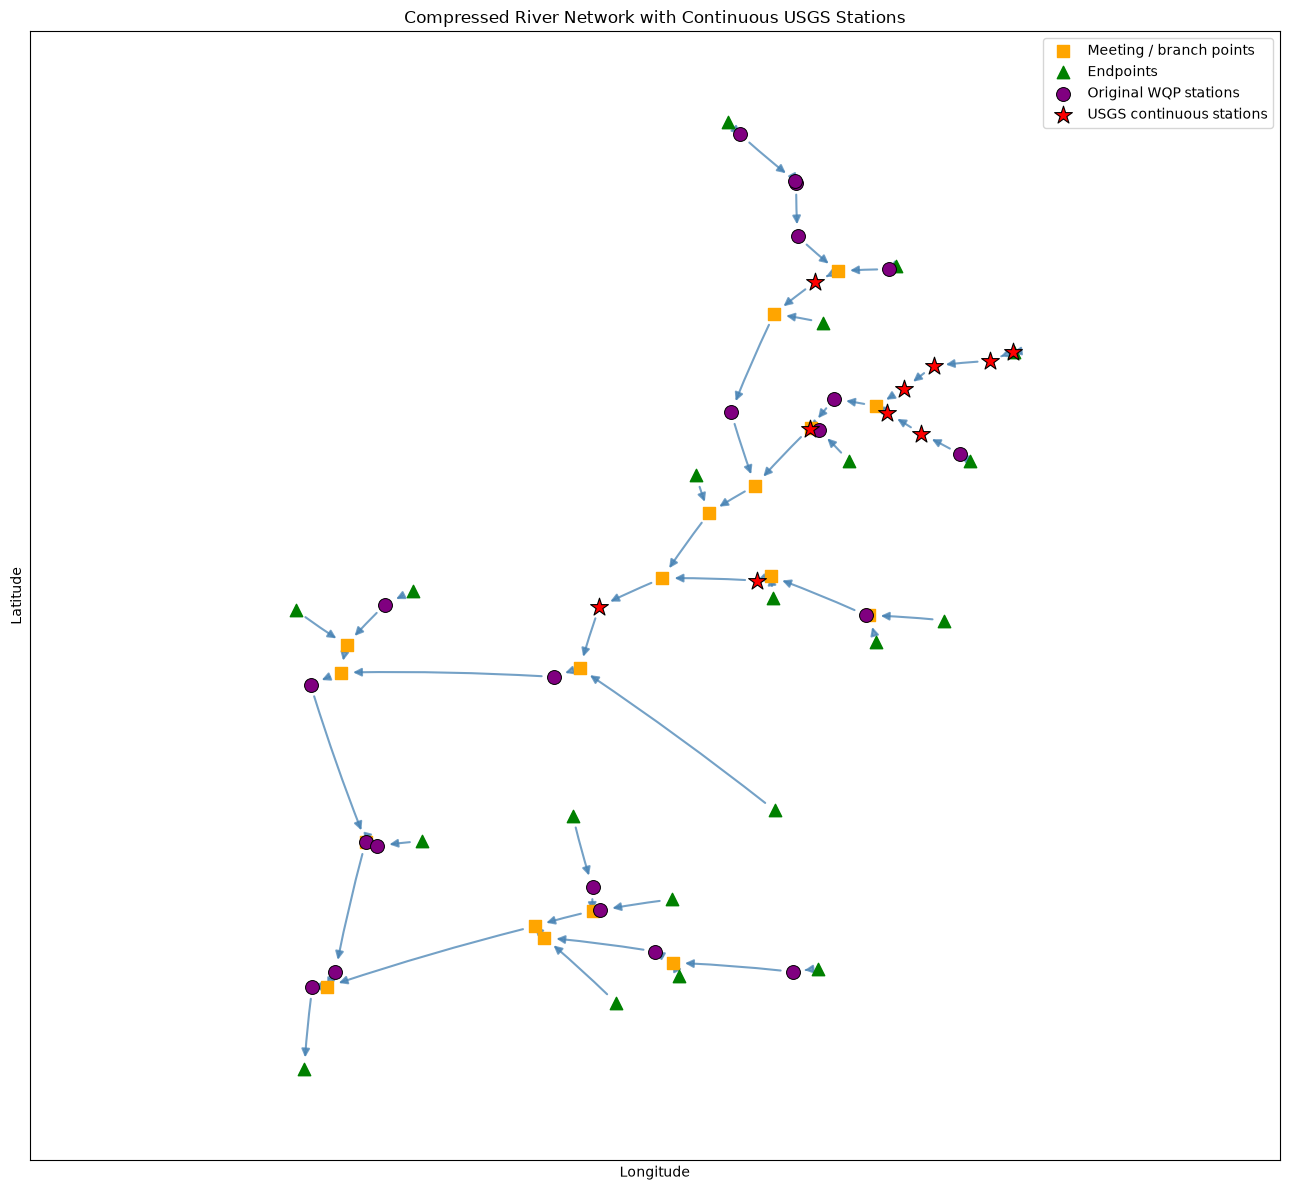

In [174]:
import matplotlib.pyplot as plt
import networkx as nx
plt.figure(figsize=(13, 12))

# -----------------------------
# River edges
# -----------------------------

nx.draw_networkx_edges(
    G_compressed,
    pos,
    edge_color="steelblue",
    width=1.5,
    alpha=0.75,
    arrows=True,
    arrowsize=12,
    arrowstyle="-|>",
    connectionstyle="arc3,rad=0.02"
)


# -----------------------------
# Other retained nodes
# -----------------------------

nx.draw_networkx_nodes(
    G_compressed,
    pos,
    nodelist=other_nodes,
    node_size=35,
    node_color="gray",
    label="Other retained nodes"
)


# -----------------------------
# Meeting / confluence nodes
# -----------------------------

nx.draw_networkx_nodes(
    G_compressed,
    pos,
    nodelist=meeting_nodes,
    node_size=80,
    node_color="orange",
    node_shape="s",
    label="Meeting / branch points"
)


# -----------------------------
# Endpoints
# -----------------------------

nx.draw_networkx_nodes(
    G_compressed,
    pos,
    nodelist=endpoint_nodes,
    node_size=80,
    node_color="green",
    node_shape="^",
    label="Endpoints"
)


# -----------------------------
# Old WQP stations
# -----------------------------

nx.draw_networkx_nodes(
    G_compressed,
    pos,
    nodelist=old_station_nodes,
    node_size=100,
    node_color="purple",
    node_shape="o",
    edgecolors="black",
    linewidths=0.7,
    label="Original WQP stations"
)


# -----------------------------
# New continuous USGS stations
# -----------------------------

nx.draw_networkx_nodes(
    G_compressed,
    pos,
    nodelist=usgs_nodes,
    node_size=180,
    node_color="red",
    node_shape="*",
    edgecolors="black",
    linewidths=0.8,
    label="USGS continuous stations"
)


plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title(
    "Compressed River Network with Continuous USGS Stations"
)

plt.legend()

plt.axis("equal")

plt.tight_layout()

plt.show()

In [175]:
usgs_labels = {}

for node in usgs_nodes:

    stations = G_compressed.nodes[node].get(
        "usgs_stations",
        []
    )

    ids = [
        station["station_id"].replace(
            "USGS-",
            ""
        )
        for station in stations
    ]

    usgs_labels[node] = "\n".join(ids)